In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')


print(f"LightGBM version: {lgb.__version__}")

LightGBM version: 4.6.0


In [2]:

print("Loading Data")


# Load raw data
df_2023 = pd.read_csv('../data/raw/sample_23.csv', index_col=0)
df_2024 = pd.read_csv('../data/raw/sample_24.csv', index_col=0)

print(f" 2023 data: {df_2023.shape}")
print(f" 2024 data: {df_2024.shape}")

# Load cluster assignments (from your clustering step)
cluster_assignments = pd.read_csv('../outputs/cluster_assignments.csv')
print(f"\n Cluster assignments loaded: {cluster_assignments.shape}")

# Display cluster distribution
print("\n Cluster distribution:")
cluster_counts = cluster_assignments['cluster'].value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    print(f"   Cluster {cluster_id}: {count} households")

household_to_cluster = dict(zip(cluster_assignments['household_id'], 
                                 cluster_assignments['cluster']))



Loading Data
 2023 data: (17547, 365)
 2024 data: (17547, 366)

 Cluster assignments loaded: (17547, 2)

 Cluster distribution:
   Cluster 0: 444 households
   Cluster 1: 14620 households
   Cluster 2: 66 households
   Cluster 3: 2417 households


In [3]:
"""
Reshaping data 
"""


print("Reshaping data for Forecasting")


def reshape_to_long(df, year):
    """
    Convert wide format (households × dates) to long format

    """
    # Reset index to make household_id a column
    df_long = df.reset_index()
    
    # Get the name of the first column (household IDs)
    id_col = df_long.columns[0]
    
    # Melt the dataframe - date columns become 'day' column
    df_long = df_long.melt(
        id_vars=[id_col], 
        var_name='date', 
        value_name='consumption'
    )
    
    # Rename the ID column
    df_long.rename(columns={id_col: 'household_id'}, inplace=True)
    
    # Convert date to datetime
    df_long['date'] = pd.to_datetime(df_long['date'])
    
    # Extract day of year (1-365 or 1-366)
    df_long['day_of_year'] = df_long['date'].dt.dayofyear
    
    # Extract other time features
    df_long['day_of_week'] = df_long['date'].dt.dayofweek  # 0=Monday, 6=Sunday
    df_long['month'] = df_long['date'].dt.month
    df_long['weekend'] = (df_long['day_of_week'] >= 5).astype(int)
    df_long['year'] = df_long['date'].dt.year
    
    # Create a sequential day number (1 to 365/366)
    # This helps with ordering
    df_long['day_seq'] = df_long.groupby('household_id').cumcount() + 1
    
    return df_long

# Reshape both datasets
print("Reshaping 2023 data...")
df_2023_long = reshape_to_long(df_2023, 2023)
print(f" 2023 long format: {df_2023_long.shape}")
print(f"   Columns: {df_2023_long.columns.tolist()}")

print("\nReshaping 2024 data...")
df_2024_long = reshape_to_long(df_2024, 2024)
print(f" 2024 long format: {df_2024_long.shape}")

print(f"\n Sample of 2023 data (first 5 rows):")
print(df_2023_long.head())

print(f"\n Sample of 2024 data (first 5 rows):")
print(df_2024_long.head())

# Verify date ranges
print(f"\n Date ranges:")
print(f"   2023: {df_2023_long['date'].min()} to {df_2023_long['date'].max()}")
print(f"   2024: {df_2024_long['date'].min()} to {df_2024_long['date'].max()}")

# Add cluster labels
try:
    cluster_assignments = pd.read_csv('../outputs/cluster_assignments.csv')
    household_to_cluster = dict(zip(cluster_assignments['household_id'], 
                                     cluster_assignments['cluster']))
    
    df_2023_long['cluster'] = df_2023_long['household_id'].map(household_to_cluster)
    df_2024_long['cluster'] = df_2024_long['household_id'].map(household_to_cluster)
    
    print(f"\n Added cluster labels to both datasets")
    print(f"  Clusters in 2023: {sorted(df_2023_long['cluster'].unique())}")
    print(f"  Clusters in 2024: {sorted(df_2024_long['cluster'].unique())}")
    
    # Check for any households without cluster assignment
    missing_clusters_2023 = df_2023_long['cluster'].isna().sum()
    missing_clusters_2024 = df_2024_long['cluster'].isna().sum()
    
    if missing_clusters_2023 > 0:
        print(f"   Warning: {missing_clusters_2023} rows in 2023 have no cluster assignment")
    if missing_clusters_2024 > 0:
        print(f"   Warning: {missing_clusters_2024} rows in 2024 have no cluster assignment")
    
except FileNotFoundError:
    print("\n Cluster assignments file not found. Creating dummy clusters...")
    df_2023_long['cluster'] = 0
    df_2024_long['cluster'] = 0
    print("   Using cluster=0 for all households (for testing)")



Reshaping data for Forecasting
Reshaping 2023 data...
 2023 long format: (6404655, 9)
   Columns: ['household_id', 'date', 'consumption', 'day_of_year', 'day_of_week', 'month', 'weekend', 'year', 'day_seq']

Reshaping 2024 data...
 2024 long format: (6422202, 9)

 Sample of 2023 data (first 5 rows):
   household_id       date  consumption  day_of_year  day_of_week  month  \
0            22 2023-01-01       13.482            1            6      1   
1            42 2023-01-01       46.427            1            6      1   
2            56 2023-01-01        9.088            1            6      1   
3            58 2023-01-01       10.040            1            6      1   
4            64 2023-01-01        2.969            1            6      1   

   weekend  year  day_seq  
0        1  2023        1  
1        1  2023        1  
2        1  2023        1  
3        1  2023        1  
4        1  2023        1  

 Sample of 2024 data (first 5 rows):
   household_id       date  consumpt

In [4]:
"""
Creating lag features for forecasting
"""


print("Creating lag Features")


def create_lag_features(df, household_col='household_id', 
                         target_col='consumption', 
                         time_col='day_seq',
                         lags=[1, 2, 3, 7, 14, 28]):
    """
    Create lag features for time series forecasting
    Uses day_seq for proper ordering
    """
    df_with_lags = df.copy()
    
    # Sort by household and day sequence to ensure proper ordering
    df_with_lags = df_with_lags.sort_values([household_col, time_col])
    
    for lag in lags:
        # Create lag for each household separately
        df_with_lags[f'lag_{lag}'] = df_with_lags.groupby(household_col)[target_col].shift(lag)
    
    return df_with_lags

# Define lag values
lags = [1, 2, 3, 7, 14, 28]

# Create lag features for 2023 data
print("Creating lag features for 2023 data...")
df_2023_lags = create_lag_features(df_2023_long, lags=lags)

# Remove rows with NaN (first few days of each household)
rows_before = len(df_2023_lags)
df_2023_lags = df_2023_lags.dropna()
rows_after = len(df_2023_lags)

print(f" Removed {rows_before - rows_after} rows with NaN lags")
print(f" Final training data: {rows_after} rows")

# Show lag features
print(f"\n Lag features created: {lags}")
print(f"\nSample data with lags (first 10 rows of one household):")
sample_household = df_2023_lags['household_id'].iloc[0]
sample_data = df_2023_lags[df_2023_lags['household_id'] == sample_household].head(10)
print(sample_data[['household_id', 'day_seq', 'consumption'] + [f'lag_{l}' for l in lags[:3]]])

# Verify no NaN values remain
print(f"\n Final check - NaN values: {df_2023_lags.isnull().sum().sum()}")

Creating lag Features
Creating lag features for 2023 data...
 Removed 491316 rows with NaN lags
 Final training data: 5913339 rows

 Lag features created: [1, 2, 3, 7, 14, 28]

Sample data with lags (first 10 rows of one household):
        household_id  day_seq  consumption   lag_1   lag_2   lag_3
491316            22       29       11.630  12.385   8.332  13.493
508863            22       30       10.220  11.630  12.385   8.332
526410            22       31       13.085  10.220  11.630  12.385
543957            22       32       10.575  13.085  10.220  11.630
561504            22       33       12.303  10.575  13.085  10.220
579051            22       34        7.309  12.303  10.575  13.085
596598            22       35       12.538   7.309  12.303  10.575
614145            22       36       12.556  12.538   7.309  12.303
631692            22       37        9.779  12.556  12.538   7.309
649239            22       38       11.061   9.779  12.556  12.538

 Final check - NaN values: 0


In [5]:
"""
Training Global model (Single model for ALL households)
"""


print("Training Global model")


# Define features for training
# Using time-based features + lag features
feature_columns = ['day_of_year', 'day_of_week', 'month', 'weekend'] + [f'lag_{l}' for l in lags]

# Verify all feature columns exist
missing_cols = [col for col in feature_columns if col not in df_2023_lags.columns]
if missing_cols:
    print(f" Missing columns: {missing_cols}")
else:
    print(f" All {len(feature_columns)} features available")

X_train = df_2023_lags[feature_columns]
y_train = df_2023_lags['consumption']

print(f"\n Training data shape: {X_train.shape}")
print(f"   Features: {feature_columns}")
print(f"   Target: consumption")

# Split for validation (80% train, 20% validation)
from sklearn.model_selection import train_test_split
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

print(f"\n   Training samples: {len(X_train_split)}")
print(f"   Validation samples: {len(X_val)}")

# Train LightGBM model
print("\n Training LightGBM model...")
global_model = lgb.LGBMRegressor(
    n_estimators=100,
    max_depth=10,
    learning_rate=0.1,
    random_state=42,
    verbose=-1,
    n_jobs=-1  
)

global_model.fit(
    X_train_split, y_train_split,
    eval_set=[(X_val, y_val)],
    eval_metric='mae',
    callbacks=[lgb.early_stopping(10, verbose=False)]
)

print(" Global model trained successfully!")

# Feature importance
print("\n Feature Importance:")
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': global_model.feature_importances_
}).sort_values('importance', ascending=False)

for i, row in feature_importance.head(10).iterrows():
    print(f"   {row['feature']:<20}: {row['importance']:.0f}")

Training Global model
 All 10 features available

 Training data shape: (5913339, 10)
   Features: ['day_of_year', 'day_of_week', 'month', 'weekend', 'lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_28']
   Target: consumption

   Training samples: 4730671
   Validation samples: 1182668

 Training LightGBM model...
 Global model trained successfully!

 Feature Importance:
   day_of_year         : 825
   lag_1               : 455
   lag_28              : 365
   lag_7               : 321
   day_of_week         : 267
   lag_14              : 263
   lag_3               : 254
   lag_2               : 238
   month               : 10
   weekend             : 2


In [7]:
"""
trained Global Model to predict energy consumption for every household for every day of 2024.


"""


print("Predicting 2024")


import time
start = time.time()

# Get unique households
households = df_2024_long['household_id'].unique()
print(f"Households: {len(households)}")

# Prepare historical data dictionary (faster method)
print("Preparing historical data...")
history = {}
for hh in households:
    hh_data = df_2023_long[df_2023_long['household_id'] == hh].sort_values('day_seq')
    history[hh] = hh_data['consumption'].tolist()

# Prepare feature matrix using list comprehension (faster)
print("Building feature matrix...")
features_list = []
for idx, row in df_2024_long.iterrows():
    hh_id = row['household_id']
    hist = history.get(hh_id, [])
    
    feat = [
        row['day_of_year'],
        row['day_of_week'], 
        row['month'],
        row['weekend'],
        hist[-1] if len(hist) >= 1 else 0,   # lag_1
        hist[-2] if len(hist) >= 2 else 0,   # lag_2
        hist[-3] if len(hist) >= 3 else 0,   # lag_3
        hist[-7] if len(hist) >= 7 else 0,   # lag_7
        hist[-14] if len(hist) >= 14 else 0, # lag_14
        hist[-28] if len(hist) >= 28 else 0  # lag_28
    ]
    features_list.append(feat)
    
    if idx % 100000 == 0:
        print(f"   Processed {idx} rows...")

import numpy as np
X = np.array(features_list)

# Predict in batches
print("Making predictions...")
predictions = global_model.predict(X)
predictions = np.maximum(predictions, 0)

df_2024_long['global_prediction'] = predictions

print(f" Done in {(time.time() - start)/60:.2f} minutes")

Predicting 2024
Households: 17547
Preparing historical data...
Building feature matrix...
   Processed 0 rows...
   Processed 100000 rows...
   Processed 200000 rows...
   Processed 300000 rows...
   Processed 400000 rows...
   Processed 500000 rows...
   Processed 600000 rows...
   Processed 700000 rows...
   Processed 800000 rows...
   Processed 900000 rows...
   Processed 1000000 rows...
   Processed 1100000 rows...
   Processed 1200000 rows...
   Processed 1300000 rows...
   Processed 1400000 rows...
   Processed 1500000 rows...
   Processed 1600000 rows...
   Processed 1700000 rows...
   Processed 1800000 rows...
   Processed 1900000 rows...
   Processed 2000000 rows...
   Processed 2100000 rows...
   Processed 2200000 rows...
   Processed 2300000 rows...
   Processed 2400000 rows...
   Processed 2500000 rows...
   Processed 2600000 rows...
   Processed 2700000 rows...
   Processed 2800000 rows...
   Processed 2900000 rows...
   Processed 3000000 rows...
   Processed 3100000 rows.

In [8]:
"""
Train 4 separate LightGBM models - one for each cluster
"""



print("Training Cluster Specific Model")


import time
start_time = time.time()

# Get unique clusters from  data
clusters = sorted(df_2023_lags['cluster'].dropna().unique())
clusters = [int(c) for c in clusters if not pd.isna(c)]
print(f" Clusters to train: {clusters}")

# Store models and results
cluster_models = {}
cluster_results = []

for cluster_id in clusters:

    print(f" Training Model for Cluster {cluster_id}")

    
    # Filter data for this cluster
    cluster_data = df_2023_lags[df_2023_lags['cluster'] == cluster_id]
    
    n_samples = len(cluster_data)
    n_households = cluster_data['household_id'].nunique()
    
    print(f"   Samples: {n_samples:,}")
    print(f"   Households: {n_households:,}")
    
    # For very small clusters, use global model as fallback
    if n_samples < 500:
        print(f"    Small cluster - using Global Model as fallback")
        cluster_models[cluster_id] = global_model
        cluster_results.append({
            'cluster': cluster_id,
            'samples': n_samples,
            'households': n_households,
            'status': 'fallback_to_global'
        })
        continue
    
    X_cluster = cluster_data[feature_columns]
    y_cluster = cluster_data['consumption']
    
    # Split for validation
    from sklearn.model_selection import train_test_split
    X_train_c, X_val_c, y_train_c, y_val_c = train_test_split(
        X_cluster, y_cluster, test_size=0.2, random_state=42
    )
    
    print(f"   Training samples: {len(X_train_c):,}")
    print(f"   Validation samples: {len(X_val_c):,}")
    
    # Train LightGBM
    cluster_model = lgb.LGBMRegressor(
        n_estimators=100,
        max_depth=8,
        learning_rate=0.1,
        random_state=42,
        verbose=-1,
        n_jobs=-1
    )
    
    cluster_model.fit(
        X_train_c, y_train_c,
        eval_set=[(X_val_c, y_val_c)],
        eval_metric='mae',
        callbacks=[lgb.early_stopping(10, verbose=False)]
    )
    
    # Calculate validation MAE
    val_pred = cluster_model.predict(X_val_c)
    val_mae = mean_absolute_error(y_val_c, val_pred)
    
    cluster_models[cluster_id] = cluster_model
    cluster_results.append({
        'cluster': cluster_id,
        'samples': n_samples,
        'households': n_households,
        'validation_mae': round(val_mae, 4),
        'status': 'trained'
    })
    
    print(f"  Validation MAE: {val_mae:.4f}")
    
    # Feature importance
    importance = pd.DataFrame({
        'feature': feature_columns,
        'importance': cluster_model.feature_importances_
    }).sort_values('importance', ascending=False).head(3)
    print(f"   Top features: {importance['feature'].iloc[0]}, {importance['feature'].iloc[1]}, {importance['feature'].iloc[2]}")



print("\n Cluster model Training Complete")


results_df = pd.DataFrame(cluster_results)
print(results_df.to_string(index=False))

elapsed = (time.time() - start_time) / 60
print(f"\n Total training time: {elapsed:.2f} minutes")

# Save models info
results_df.to_csv('../outputs/cluster_models_summary.csv', index=False)


Training Cluster Specific Model
 Clusters to train: [0, 1, 2, 3]
 Training Model for Cluster 0
   Samples: 149,628
   Households: 444
   Training samples: 119,702
   Validation samples: 29,926
  Validation MAE: 0.5050
   Top features: lag_1, day_of_year, lag_3
 Training Model for Cluster 1
   Samples: 4,926,940
   Households: 14,620
   Training samples: 3,941,552
   Validation samples: 985,388
  Validation MAE: 1.5684
   Top features: day_of_year, lag_1, lag_28
 Training Model for Cluster 2
   Samples: 22,242
   Households: 66
   Training samples: 17,793
   Validation samples: 4,449
  Validation MAE: 0.3069
   Top features: lag_1, day_of_year, lag_3
 Training Model for Cluster 3
   Samples: 814,529
   Households: 2,417
   Training samples: 651,623
   Validation samples: 162,906
  Validation MAE: 4.9437
   Top features: day_of_year, lag_1, lag_7

 Cluster model Training Complete
 cluster  samples  households  validation_mae  status
       0   149628         444          0.5050 trained
 

In [9]:
"""
Predicting global model
"""


print("Predicting Global Model")


print("\n Preparing 2024 features...")

# Create historical lookup (last values from 2023 for each household)
historical = {}
for hh_id in df_2024_long['household_id'].unique():
    hh_2023 = df_2023_long[df_2023_long['household_id'] == hh_id].sort_values('day_seq')
    historical[hh_id] = hh_2023['consumption'].tolist()

# Build feature matrix for 2024
X_2024_list = []
for idx, row in df_2024_long.iterrows():
    hh_id = row['household_id']
    hist = historical.get(hh_id, [])
    
    features = [
        row['day_of_year'],
        row['day_of_week'],
        row['month'],
        row['weekend'],
        hist[-1] if len(hist) >= 1 else 0,
        hist[-2] if len(hist) >= 2 else 0,
        hist[-3] if len(hist) >= 3 else 0,
        hist[-7] if len(hist) >= 7 else 0,
        hist[-14] if len(hist) >= 14 else 0,
        hist[-28] if len(hist) >= 28 else 0,
    ]
    X_2024_list.append(features)

X_2024 = np.array(X_2024_list)
print(f" Feature matrix shape: {X_2024.shape}")


print("\n Making predictions with Global Model...")
global_predictions = global_model.predict(X_2024)
global_predictions = np.maximum(global_predictions, 0)  # No negative consumption

df_2024_long['global_prediction'] = global_predictions
print(f" Added 'global_prediction' column to df_2024_long")


print("\n Sample predictions (first 10 rows):")
print(df_2024_long[['household_id', 'day_seq', 'consumption', 'global_prediction']].head(10))

# Calculate sample MAE
from sklearn.metrics import mean_absolute_error
sample_mae = mean_absolute_error(
    df_2024_long['consumption'].head(1000),
    df_2024_long['global_prediction'].head(1000)
)
print(f"\n Sample MAE (first 1000 rows): {sample_mae:.4f}")

print("\n Global predictions complete! Ready for evaluation.")

Predicting Global Model

 Preparing 2024 features...
 Feature matrix shape: (6422202, 10)

 Making predictions with Global Model...
 Added 'global_prediction' column to df_2024_long

 Sample predictions (first 10 rows):
   household_id  day_seq  consumption  global_prediction
0            22        1        9.932          10.259027
1            42        1       33.312          41.327616
2            56        1        6.133           7.395832
3            58        1       16.701          15.795706
4            64        1        3.210           2.557788
5            88        1       25.246          18.653997
6            95        1       13.485          15.092534
7           163        1       16.847          16.600537
8           198        1       22.577          22.567748
9           202        1        5.939           5.655997

 Sample MAE (first 1000 rows): 2.4497

 Global predictions complete! Ready for evaluation.


In [10]:
"""
Using the 4 cluster-specific models to predict 2024 consumption
"""


print("Predicting 2024 with Cluster models")


import time
start_time = time.time()

# Prepare historical data once
print("Preparing historical data...")
households = df_2024_long['household_id'].unique()
history = {}
for hh in households:
    hh_data = df_2023_long[df_2023_long['household_id'] == hh].sort_values('day_seq')
    history[hh] = hh_data['consumption'].tolist()

print(f" Historical data loaded for {len(households):,} households")

# Build features and predict by cluster (faster)
print("\nBuilding features and predicting...")

# Add cluster prediction column
df_2024_long['cluster_prediction'] = 0.0

# Process each cluster separately
for cluster_id in clusters:
    print(f"\n   Processing Cluster {cluster_id}...")
    
    # Get model for this cluster
    model = cluster_models.get(cluster_id, global_model)
    
    # Get households in this cluster
    cluster_mask = df_2024_long['cluster'] == cluster_id
    cluster_indices = df_2024_long[cluster_mask].index
    n_predictions = len(cluster_indices)
    
    print(f"      Households: {df_2024_long[cluster_mask]['household_id'].nunique():,}")
    print(f"      Predictions: {n_predictions:,}")
    
    # Build features for this cluster
    features_list = []
    for idx in cluster_indices:
        row = df_2024_long.loc[idx]
        hh_id = row['household_id']
        hist = history.get(hh_id, [])
        
        feat = [
            row['day_of_year'],
            row['day_of_week'],
            row['month'],
            row['weekend'],
            hist[-1] if len(hist) >= 1 else 0,
            hist[-2] if len(hist) >= 2 else 0,
            hist[-3] if len(hist) >= 3 else 0,
            hist[-7] if len(hist) >= 7 else 0,
            hist[-14] if len(hist) >= 14 else 0,
            hist[-28] if len(hist) >= 28 else 0
        ]
        features_list.append(feat)
    
    # Predict in batches
    import numpy as np
    X_cluster = np.array(features_list)
    
    batch_size = 100000
    predictions = []
    
    for i in range(0, len(X_cluster), batch_size):
        batch = X_cluster[i:i+batch_size]
        batch_pred = model.predict(batch)
        predictions.extend(batch_pred)
    
    predictions = np.maximum(predictions, 0)
    
    # Assign predictions
    df_2024_long.loc[cluster_indices, 'cluster_prediction'] = predictions
    
    print(f"       Done - MAE pending evaluation")




elapsed = (time.time() - start_time) / 60
print(f" Total prediction time: {elapsed:.2f} minutes")

# Sample output
print("\n Sample predictions:")
sample_df = df_2024_long[['household_id', 'cluster', 'day_seq', 
                           'consumption', 'global_prediction', 
                           'cluster_prediction']].head(15)
print(sample_df.to_string(index=False))

Predicting 2024 with Cluster models
Preparing historical data...
 Historical data loaded for 17,547 households

Building features and predicting...

   Processing Cluster 0...
      Households: 444
      Predictions: 162,504
       Done - MAE pending evaluation

   Processing Cluster 1...
      Households: 14,620
      Predictions: 5,350,920
       Done - MAE pending evaluation

   Processing Cluster 2...
      Households: 66
      Predictions: 24,156
       Done - MAE pending evaluation

   Processing Cluster 3...
      Households: 2,417
      Predictions: 884,622
       Done - MAE pending evaluation
 Total prediction time: 3.16 minutes

 Sample predictions:
 household_id  cluster  day_seq  consumption  global_prediction  cluster_prediction
           22        1        1        9.932          10.259027           10.118268
           42        3        1       33.312          41.327616           45.116232
           56        1        1        6.133           7.395832            8.012

 Model Evaluation

 STEP 1: Calculating MAE per household
Total households: 17,547
   Processed 5,000/17,547 households
   Processed 10,000/17,547 households
   Processed 15,000/17,547 households

 STEP 2: Calculating overall averages
 FINAL MAE RESULTS



RESULTS:

   Global Model (1 model):      MAE = 5.3218
   Cluster Model (4 models):    MAE = 5.2709

   Improvement:                  +0.0509 (+0.96%)

 CONCLUSION: Cluster Model WINS by 0.0509 MAE points!

 STEP 3: MAE breakdown by cluster

MAE per cluster:
         mae_global  mae_cluster  n_households
cluster                                       
0            1.7683       1.6732           444
1            3.2226       3.1541         14620
2            0.6910       0.7151            66
3           18.7988      18.8604          2417

 STEP 4: Generating visualizations


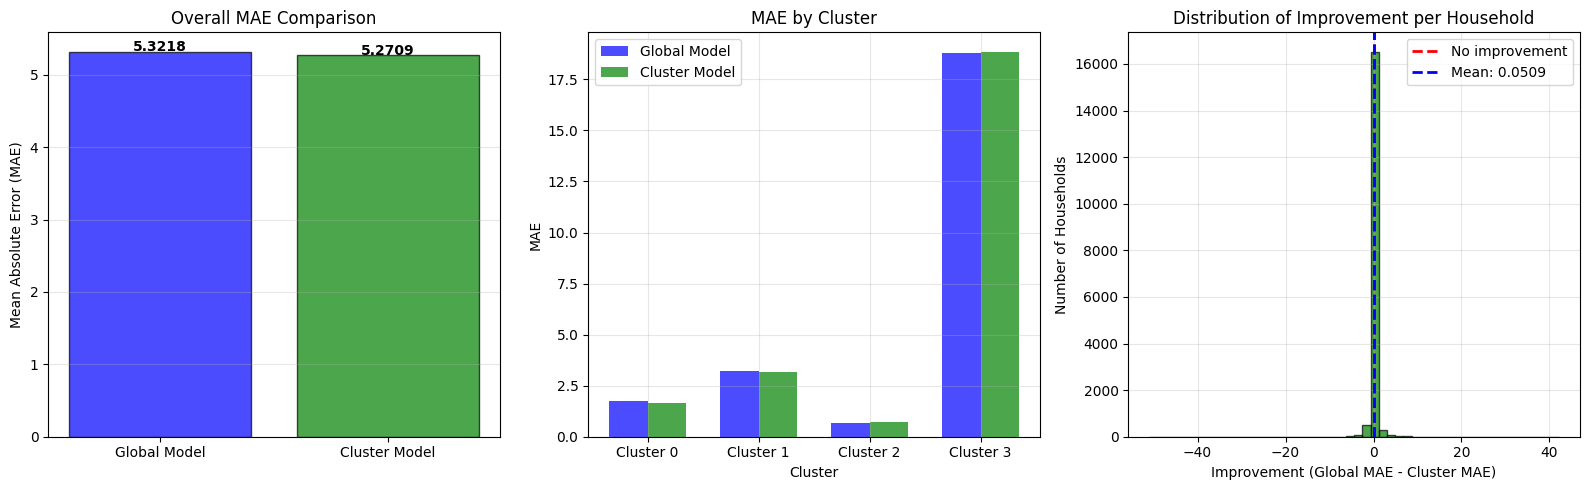


 STEP 5: Saving results
--------------------------------------------------
 Saved: ../outputs/final_results.csv
 Saved: ../outputs/final_report.txt
 EVALUATION COMPLETE!
 Total evaluation time: 0.61 minutes

 Output files generated:
   - ../outputs/final_results.csv (MAE per household)
   - ../outputs/final_comparison.png (visualizations)
   - ../outputs/final_report.txt (summary report)


In [11]:
"""
Comparing Models
"""


print(" Model Evaluation")


from sklearn.metrics import mean_absolute_error
import time

start_time = time.time()


print("\n  Calculating MAE per household")


household_results = []
households = df_2024_long['household_id'].unique()
print(f"Total households: {len(households):,}")

for i, household_id in enumerate(households):
    # Get all 366 days for this household
    hh_data = df_2024_long[df_2024_long['household_id'] == household_id]
    
    # Actual values (real consumption from 2024)
    actual = hh_data['consumption'].values
    
    # Predicted values from Global Model
    global_pred = hh_data['global_prediction'].values
    
    # Predicted values from Cluster Model
    cluster_pred = hh_data['cluster_prediction'].values
    
    # Calculate MAE (Mean Absolute Error) over 366 days
    # Formula: MAE = (1/366) * sum(|actual - predicted|)
    mae_global = mean_absolute_error(actual, global_pred)
    mae_cluster = mean_absolute_error(actual, cluster_pred)
    
    # Get cluster for this household
    hh_cluster = hh_data['cluster'].iloc[0]
    if pd.isna(hh_cluster):
        hh_cluster = -1
    else:
        hh_cluster = int(hh_cluster)
    
    household_results.append({
        'household_id': household_id,
        'cluster': hh_cluster,
        'mae_global': mae_global,
        'mae_cluster': mae_cluster,
        'improvement': mae_global - mae_cluster  # Positive = cluster better
    })
    
    # Progress every 5000 households
    if (i + 1) % 5000 == 0:
        print(f"   Processed {i+1:,}/{len(households):,} households")

results_df = pd.DataFrame(household_results)


print("\n Calculating overall averages")


avg_global = results_df['mae_global'].mean()
avg_cluster = results_df['mae_cluster'].mean()
improvement = avg_global - avg_cluster
improvement_pct = (improvement / avg_global) * 100


print(" Final MAE Result")

print(f"""


RESULTS:

   Global Model (1 model):      MAE = {avg_global:.4f}
   Cluster Model (4 models):    MAE = {avg_cluster:.4f}

   Improvement:                  {improvement:+.4f} ({improvement_pct:+.2f}%)
""")

if improvement > 0:
    print(f" CONCLUSION: Cluster Model WINS by {improvement:.4f} MAE points!")
else:
    print(f" CONCLUSION: Global Model WINS by {-improvement:.4f} MAE points")


print("\n  MAE breakdown by cluster")


cluster_perf = results_df.groupby('cluster').agg({
    'mae_global': 'mean',
    'mae_cluster': 'mean',
    'household_id': 'count'
}).rename(columns={'household_id': 'n_households'})

print("\nMAE per cluster:")
print(cluster_perf.round(4))


print("\n STEP 4: Generating visualizations")


import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Overall MAE comparison
models = ['Global Model', 'Cluster Model']
mae_values = [avg_global, avg_cluster]
colors = ['blue', 'green']
axes[0].bar(models, mae_values, color=colors, alpha=0.7, edgecolor='black')
axes[0].set_ylabel('Mean Absolute Error (MAE)')
axes[0].set_title('Overall MAE Comparison')
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(mae_values):
    axes[0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

# Plot 2: MAE by cluster
clusters = sorted([c for c in cluster_perf.index if c >= 0])
x = range(len(clusters))
width = 0.35

global_vals = [cluster_perf.loc[c, 'mae_global'] for c in clusters]
cluster_vals = [cluster_perf.loc[c, 'mae_cluster'] for c in clusters]

axes[1].bar([i - width/2 for i in x], global_vals, width, label='Global Model', color='blue', alpha=0.7)
axes[1].bar([i + width/2 for i in x], cluster_vals, width, label='Cluster Model', color='green', alpha=0.7)
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('MAE')
axes[1].set_title('MAE by Cluster')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'Cluster {c}' for c in clusters])
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Distribution of improvements
axes[2].hist(results_df['improvement'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[2].axvline(x=0, color='red', linestyle='--', linewidth=2, label='No improvement')
axes[2].axvline(x=results_df['improvement'].mean(), color='blue', linestyle='--', 
                linewidth=2, label=f'Mean: {results_df["improvement"].mean():.4f}')
axes[2].set_xlabel('Improvement (Global MAE - Cluster MAE)')
axes[2].set_ylabel('Number of Households')
axes[2].set_title('Distribution of Improvement per Household')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


print("\n Saving results")

import os
os.makedirs('../outputs', exist_ok=True)

results_df.to_csv('../outputs/final_results.csv', index=False)
print(" Saved: ../outputs/final_results.csv")


summary_report = f"""
FORECASTING PROJECT - FINAL REPORT


DATA SUMMARY:
- Total households: {len(households):,}
- Training data: 2023 (365 days)
- Testing data: 2024 (366 days, leap year)
- Number of clusters: 4

CLUSTER DISTRIBUTION:
{cluster_perf.to_string()}

MAE RESULTS:
- Global Model (1 model):   {avg_global:.4f}
- Cluster Model (4 models): {avg_cluster:.4f}
- Improvement:              {improvement:+.4f} ({improvement_pct:+.2f}%)

CONCLUSION:
The {'Cluster' if improvement > 0 else 'Global'} model performs better by {abs(improvement):.4f} MAE points.


"""

with open('../outputs/final_report.txt', 'w') as f:
    f.write(summary_report)
print(" Saved: ../outputs/final_report.txt")




